## KNN Scratch Implementation For Binary Classification

In [3]:
import numpy as np
import seaborn as sns
import pandas as pd

In [2]:
# Data
X_train = np.array([
    [1, 2],
    [2, 3],
    [3, 3],
    [6, 5],
    [7, 7]
])

y_train = np.array([0, 0, 0, 1, 1])

X_test = np.array([
    [2, 2],
    [6, 6]
])

<Axes: xlabel='x1', ylabel='x2'>

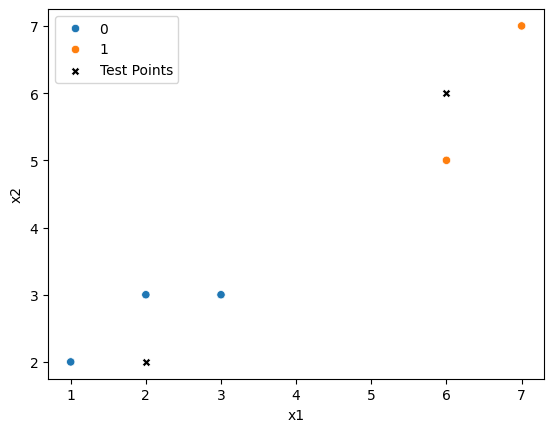

In [9]:
# Visualization

X_train_df = pd.DataFrame(X_train, columns=["x1", "x2"])
X_train_df["label"] = y_train

sns.scatterplot(data=X_train_df, x="x1", y="x2", hue="label")

X_test_df = pd.DataFrame(X_test, columns=["x1", "x2"])

sns.scatterplot(data=X_test_df, x="x1", y="x2", color="black", marker="X", label="Test Points")


In [5]:
X_train_df

,x1,x2,label
0,1,2,0
1,2,3,0
2,3,3,0
3,6,5,1
4,7,7,1


In [ ]:
class KnnClassifier:
    def __init__(self, k=3):
        self.k = k

    # To calculate euclidean distance
    def eucli_dist(self, x1, x2):
        return np.sqrt(np.sum((x1-x2)**2))

    def fit(self, X, y): # does noting at first a lazy learner in 
        self.X_train = X
        self.y_train = y

    def _predict(self, x): # small x is a single input point
        distances = [self.eucli_dist(x, x_train) for x_train in self.X_train] # cal dist for all data points
        knn_idx = np.argsort(distances)[:self.k] # getting index of k nearest neighbors
        knn_class = [self.y_train[i] for i in knn_idx] # getting class of k nearest neighbors
        majr_class = np.argmax(np.bincount(knn_class)) # getting majority class
        return majr_class

    def predict(self, X): # capital X a set of input points
        y_pred = [self._predict(x) for x in X]
        return np.array(y_pred)


In [ ]:
# An example to calculate euclidean distance between two points
x1 = np.array([1, 2])
x2 = np.array([3, 4])

np.sqrt(np.sum((x1-x2)**2))

2.8284271247461903

In [ ]:
distances = [5, 2, 4, 1, 0]

np.argsort(distances) # Sorted Index values

knn_demo = [0, 0, 1, 1, 0, 0, 3, 3, 5]
np.argmax(np.bincount(knn_demo)) # Shows max freq class in the list

0

In [20]:
model = KnnClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(y_pred)

[0 1]
